In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [1]:
from functools import partial

import datasets as hfds
import torch
import numpy as np
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from einops import rearrange
import torch.nn.functional as F
from matplotlib.patches import Rectangle

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.models_mae as models_mae
import flat_mae.masking as flat_masking
import flat_mae.nisc as nisc
import flat_mae.utils as ut

In [3]:
torch.backends.cudnn.benchmark = True

In [2]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [5]:
# get some data
# note, hardcoded params from the config
dataset_root = "s3://medarc/fmri-datasets/eval"
space = "flat"
img_size = (224, 560)
patch_size = 16
t_patch_size = 4
masking = "tube"
mask_ratio = 0.9
batch_size = 32

transform = flat_transforms.make_transform(space)
dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/test/*.arrow",
    split="train",
)
dataset = flat_data.HFDataset(dataset, transform)
mask_fn = flat_masking.create_masking(
    name=masking,
    mask_ratio=mask_ratio,
    img_size=img_size,
    patch_size=patch_size,
    t_patch_size=t_patch_size,
)
collate_fn = partial(flat_masking.mask_collate, mask_fn=mask_fn)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=8,
    drop_last=False,
)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
device = torch.device("cuda")

In [7]:
keys = [
    "attn_reg1",
    "attn_reg1_pep4",
    # "cross_reg1",
    # "cross_reg1_pep4"
]
models = {}

for key in keys:
    ckpt_path = f"output/decoders/{key}/pretrain/checkpoint-last.pth"
    models[key] = models_mae.MaskedAutoencoderViT.from_checkpoint(ckpt_path).to(device)

In [8]:
weight_maps = {}
for key in keys:
    weight = models[key].decoder.head.weight.data.cpu()
    weight = rearrange(weight.T, "(h w) (t p q) -> t h w p q", h=16, p=16, t=2)
    weight = F.pad(weight, (1, 1, 1, 1), value=float("nan"))
    weight = rearrange(weight, "t h w p q -> t (h p) (w q)")
    weight = F.pad(weight, (1, 1, 1, 1), value=float("nan"))
    weight_maps[key] = weight.numpy()

0.8043750000000001


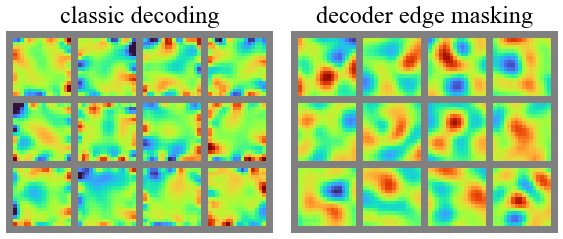

In [27]:
vmax = 0.08
p = 18
nr = 3
nc = 4

cmap = plt.get_cmap("turbo")
cmap.set_bad("gray")

titles = ["classic decoding", "decoder edge masking"]

figw = 0.6 * PLOTW
figh = 1.1 * nr / (2 * nc) * figw
f, axs = plt.subplots(1, 2, figsize=(figw, figh))

for ii, key in enumerate(keys):
    plt.sca(axs[ii])
    plt.imshow(weight_maps[key][0, : nr * p + 2, : nc * p + 2], vmin=-vmax, vmax=vmax, cmap=cmap)
    plt.title(titles[ii], fontsize="small")
    plt.axis("off")

plt.tight_layout(pad=0.5)
f.savefig("results/edge_mask_head_maps.pdf")
print(figh)

In [13]:
ut.random_seed(42)
batch = next(iter(loader))
bold = batch["bold"].to(device)
mask = batch["mask"].to(device)
visible_mask = batch["visible_mask"].to(device)

with torch.inference_mode():
    _, state1 = models["attn_reg1"](
        bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=mask_ratio
    )
    _, state2 = models["attn_reg1_pep4"](
        bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=mask_ratio
    )

In [14]:
example_idx = 24
img = state1["images"][example_idx].cpu().numpy()
vmask = state1["visible_mask"][example_idx].cpu().numpy()
vids = state1["visible_ids"][example_idx].cpu().numpy()
pred1 = state1["pred_images"][example_idx].cpu().numpy()
pred2 = state2["pred_images"][example_idx].cpu().numpy()

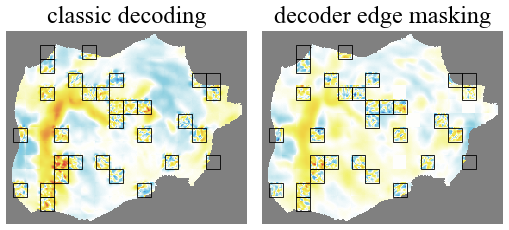

In [26]:
# figw = 0.8 * PLOTW
# figh = 1.2
f, axs = plt.subplots(1, 2, figsize=(0.9 * figw, figh))
ax1, ax2 = axs

immask = img[0, 0] == 0
im_paste1 = (img * vmask) + (1 - vmask) * pred1
im_paste2 = (img * vmask) + (1 - vmask) * pred2

ax1.imshow(
    np.where(immask, np.nan, im_paste1[0, 7]),
    vmin=-3,
    vmax=3,
    cmap=nisc.FC_CMAP,
    interpolation="none",
)

h, w = 14, 35
p = 16
for idx in vids:
    tidx = idx // (h * w)
    if tidx == 0:
        idx = idx % (h * w)
        ridx = idx // w
        cidx = idx % w
        box = Rectangle((p * cidx, p * ridx), p, p, fc="none", ec="k", lw=0.2)
        ax1.add_artist(box)

ax1.set_axis_off()
ax1.set_xlim(560 / 2, 560)
ax1.set_title("classic decoding", fontsize="small")

ax2.imshow(
    np.where(immask, np.nan, im_paste2[0, tidx]),
    vmin=-3,
    vmax=3,
    cmap=nisc.FC_CMAP,
    interpolation="none",
)
for idx in vids:
    tidx = idx // (h * w)
    if tidx == 0:
        idx = idx % (h * w)
        ridx = idx // w
        cidx = idx % w
        box = Rectangle((p * cidx, p * ridx), p, p, fc="none", ec="k", lw=0.2)
        ax2.add_artist(box)
ax2.set_axis_off()
ax2.set_xlim(560 / 2, 560)
ax2.set_title("decoder edge masking", fontsize="small")

plt.tight_layout(pad=0.5)
f.savefig("results/edge_mask_recon.pdf")

In [16]:
mae_ckpt = torch.load("output/mae_pretrain_vit_base.pth", map_location="cpu")
mae_state = mae_ckpt["model"]

In [18]:
# 2 x 16 x 16
print(mae_state["patch_embed.proj.weight"].shape)

torch.Size([768, 3, 16, 16])


In [19]:
# mae_weight = mae_state["decoder_embed.weight"]
mae_weight = mae_state["patch_embed.proj.weight"]
mae_weight = rearrange(mae_weight[:, 0, :, :], "(h w) p q -> h w p q", h=16)
mae_weight = F.pad(mae_weight, (1, 1, 1, 1), value=float("nan"))
mae_weight = rearrange(mae_weight, "h w p q -> (h p) (w q)")
mae_weight = F.pad(mae_weight, (1, 1, 1, 1), value=float("nan"))
mae_weight_map = mae_weight.numpy()

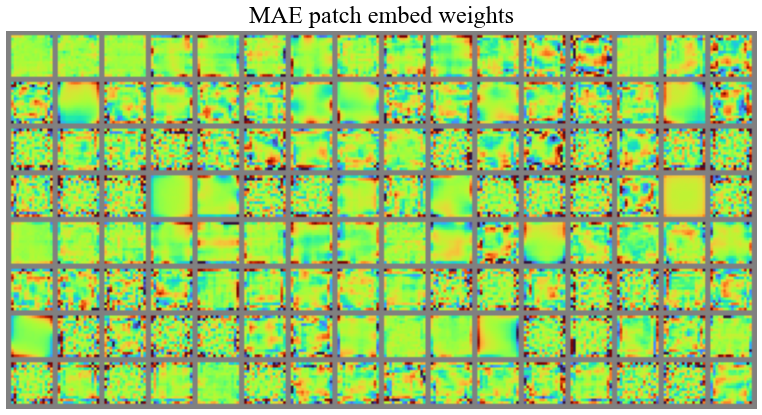

In [27]:
vmax = 0.08
p = 18
nr = 8
nc = 16

cmap = plt.get_cmap("turbo")
cmap.set_bad("gray")

figw = 0.8 * PLOTW
figh = 1.1 * nr / (1 * nc) * figw
f, axs = plt.subplots(1, 1, figsize=(figw, figh))

plt.imshow(mae_weight_map[: nr * p + 2, : nc * p + 2], vmin=-vmax, vmax=vmax, cmap=cmap)
plt.title("MAE patch embed weights", fontsize="small")
plt.axis("off")

plt.tight_layout(pad=0.5)
f.savefig("results/mae_patch_embed.pdf")

In [28]:
f.get_size_inches()

array([2.6 , 1.43])